In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import itertools
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

# 보리님 y값에서 train, test를 달리 설정하기

In [3]:
%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']='Malgun Gothic'

In [4]:
df = pd.read_csv("../../DB/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


In [5]:
year_columns = ['연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

# 연도 변수 생성
df['연도'] = df[year_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)

# 기존 더미 변수 삭제
df = df.drop(columns=year_columns + ['log_혼합배출_후_재활용량'])
df.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022


In [6]:
df.shape

(590, 20)

# Data Split

## 부산 2023은 예측으로 빼놓기

In [7]:
# 부산 2023
busan_2023 = df[(df['시도'] == '부산')&(df['연도'] == 2023)].reset_index(drop=True)
busan_2023.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,부산_강서구,11805.7,부산,강서구,62238,142396,0.1790,0.7894,0.0068,0.0159,0.0090,15487,16690,-1203,0.30575,0.267591,0.207005,0.176826,0.042828,2023
1,부산_금정구,24013.1,부산,금정구,105906,215590,0.1773,0.5656,0.0347,0.2080,0.0144,20637,25016,-4379,0.40046,0.295430,0.174782,0.104118,0.025210,2023


In [8]:
busan_2023.shape

(16, 20)

## 부산 2023 을 뺀 데이터 프레임

In [9]:
df_1 = df[~((df['시도'] == '부산')&(df['연도'] == 2023))].reset_index(drop=True)
df_1.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,0.0280,3262,2989,273,0.415669,0.353801,0.134385,0.071040,0.025105,2023


In [10]:
df_1.shape

(574, 20)

In [11]:
print(574* 0.8) # train
print(574* 0.2) # test

459.20000000000005
114.80000000000001


In [12]:
df_1[df_1['연도'] == 2023].shape
# 부산을 제외한 전국 2023

(114, 20)

In [13]:
df_1.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도'],
      dtype='object')

주민등록세대수, 총전출 은 변수(총인구수, 총전입입)간 상관관계가 너무 큼

In [14]:
# 기본 데이터 split
rf_x_train = df_1[df_1['연도'] != 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동']]
rf_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']]

rf_x_test = df_1[df_1['연도'] == 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동']]
rf_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']]

In [16]:
# 보리님의 코드
# train_test_split는 사용하지 않고 미리 전역에서 설정한 rf_x,y 데이터들로 사용하기

# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임 x
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = rf_y_train['혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            # X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            X_train = X_sub
            X_test = rf_x_test[selected_features]
            
            y_train = y_all
            y_test = rf_y_test['혼합배출_후_재활용량']
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최고 R2 ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['R2'].idxmax()])
    
    return results_df_sorted

### 3~13개 전부

In [44]:

# feature 리스트 정의
my_selected_features_set1 = [
  '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=13
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 13개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/286 완료 - R2: 0.0139, MSE: 270032951.9438
  > 조합 200/286 완료 - R2: 0.2481, MSE: 205896296.4558
  > 조합 286/286 완료 - R2: 0.0731, MSE: 253835805.5156

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/715 완료 - R2: 0.2247, MSE: 212301069.7648
  > 조합 200/715 완료 - R2: 0.2061, MSE: 217402040.4890
  > 조합 300/715 완료 - R2: 0.0486, MSE: 260530967.3031
  > 조합 400/715 완료 - R2: 0.0191, MSE: 268607747.2605
  > 조합 500/715 완료 - R2: 0.2514, MSE: 205004397.6964
  > 조합 600/715 완료 - R2: 0.0259, MSE: 266750863.2868
  > 조합 700/715 완료 - R2: 0.1782, MSE: 225050877.3693
  > 조합 715/715 완료 - R2: 0.0929, MSE: 248416421.7152

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/1287 완료 - R2: 0.4900, MSE: 139650336.6253
  > 조합 200/1287 완료 - R2: 0.1897, MSE: 221891949.3066
  > 조합 300/1287 완료 - R2: 0.3974, MSE: 165025263.7904
  > 조합 400/1287 완료 - R2: 0.4148, MSE: 160248493.4478
  > 조합 500/1287 완료 - R2: 0.1920, MSE: 221264040.8265
  > 조합 600/1287 완료 - R2: 0.2367, MSE: 209

,num_features,selected_features,R2,MSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.546690,1.241359e+08,"[0.5216920440904979, 0.26551158307707384, 0.21..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.543929,1.248920e+08,"[0.45636391231257756, 0.22859889237583508, 0.1..."
2,4,"[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율]",0.527153,1.294860e+08,"[0.4611469425426695, 0.1507102537762848, 0.232..."


### 총인구수 vs 주민등록세대수로 -> 주민등록세대수로 변경
### 총전출 추가

In [20]:
rf_x_train = df_1[df_1['연도'] != 2023][['주민등록세대수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입','총전출', '순이동']]
rf_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']]

rf_x_test = df_1[df_1['연도'] == 2023][['주민등록세대수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입','총전출', '순이동']]
rf_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']]

In [22]:
# feature 리스트 정의
my_selected_features_set1 = ['주민등록세대수','다세대주택비율', '2인가구_비율','3인가구_비율','총전입', '총전출', '순이동',
                              '단독주택비율','5인이상가구_비율', '1인가구_비율',  '4인가구_비율'
                              ]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=5
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 11개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/165 완료 - R2: 0.1211, MSE: 240683103.3197
  > 조합 165/165 완료 - R2: 0.0679, MSE: 255236765.4954

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/330 완료 - R2: 0.3024, MSE: 191028480.3603
  > 조합 200/330 완료 - R2: 0.0184, MSE: 268813392.0272
  > 조합 300/330 완료 - R2: 0.3205, MSE: 186079702.4989
  > 조합 330/330 완료 - R2: 0.2380, MSE: 208663932.3163

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/462 완료 - R2: 0.4383, MSE: 153810271.6232
  > 조합 200/462 완료 - R2: 0.1518, MSE: 232266927.9076
  > 조합 300/462 완료 - R2: 0.2668, MSE: 200784320.1085
  > 조합 400/462 완료 - R2: 0.3623, MSE: 174635841.5513
  > 조합 462/462 완료 - R2: 0.0975, MSE: 247133858.8570

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                      selected_features        R2  \
1               3            [주민등록세대수, 다세대주택비율, 3인가구_비율]  0.506979   
174             4       [주민등록세대수, 다세대주택비율, 3인가구_비율, 총전출]  0.518606   
523             5  [주민등록세대수, 다세대주택비율, 3인가구_비율, 총전입, 총전출] 

,num_features,selected_features,R2,MSE,feature_importances
0,4,"[주민등록세대수, 다세대주택비율, 3인가구_비율, 총전출]",0.518606,1.318263e+08,"[0.441020692008693, 0.23053765117848213, 0.188..."
1,5,"[주민등록세대수, 다세대주택비율, 3인가구_비율, 총전입, 총전출]",0.515701,1.326218e+08,"[0.40835206115446127, 0.21454773178001313, 0.1..."
2,4,"[주민등록세대수, 다세대주택비율, 3인가구_비율, 총전입]",0.507853,1.347711e+08,"[0.4603884361156043, 0.23398258760718307, 0.18..."


- > 총인구수가 R2가 높음

In [26]:
rf_x_train = df_1[df_1['연도'] != 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입','총전출', '순이동']]
rf_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']]

rf_x_test = df_1[df_1['연도'] == 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입','총전출', '순이동']]
rf_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']]

> 총전출을 포함하기

In [27]:
# feature 리스트 정의
my_selected_features_set1 = ['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입','총전출', '순이동'
                              ]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=6
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 14개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/364 완료 - R2: 0.2061, MSE: 217397488.5663
  > 조합 200/364 완료 - R2: 0.1296, MSE: 238358898.4917
  > 조합 300/364 완료 - R2: 0.2233, MSE: 212705264.9253
  > 조합 364/364 완료 - R2: 0.0067, MSE: 272014455.1102

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/1001 완료 - R2: 0.2506, MSE: 205215038.4425
  > 조합 200/1001 완료 - R2: 0.4321, MSE: 155523567.5317
  > 조합 300/1001 완료 - R2: 0.2898, MSE: 194489462.4702
  > 조합 400/1001 완료 - R2: 0.3795, MSE: 169919894.3102
  > 조합 500/1001 완료 - R2: 0.3518, MSE: 177501278.3165
  > 조합 600/1001 완료 - R2: 0.1388, MSE: 235845073.5744
  > 조합 700/1001 완료 - R2: 0.3739, MSE: 171463428.7435
  > 조합 800/1001 완료 - R2: 0.1344, MSE: 237033979.7715
  > 조합 900/1001 완료 - R2: 0.3964, MSE: 165283391.0496
  > 조합 1000/1001 완료 - R2: 0.0803, MSE: 251843132.1746
  > 조합 1001/1001 완료 - R2: 0.0414, MSE: 262519239.2916

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/2002 완료 - R2: 0.2591, MSE: 202883707.6264
  > 조합 200/2002 완료 - R2: 0.3942,

,num_features,selected_features,R2,MSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.546690,1.241359e+08,"[0.5216920440904979, 0.26551158307707384, 0.21..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.543929,1.248920e+08,"[0.45636391231257756, 0.22859889237583508, 0.1..."
2,5,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입, 총전출]",0.542491,1.252858e+08,"[0.39090460836185875, 0.22073277170267974, 0.1..."


# 피처 선정 결과:
- 총전출을 추가했지만 [총인구수, 다세대주택비율, 3인가구_비율]의 R2가 가장 높음  
<br>
- 회귀에서 선정한 피처 : ['총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']
- KBR 보리님이 선정한 피처 : [총인구수, 단독주택비율, 2인가구_비율, 4인가구_비율]

다음 과정:  
1. 선정피처와, 회귀, KBR보리님 피처 비교해서 하나 선정하기 
2. 부산예측값 결론내기  
3. 로그 모델을 만들시간이 되면 만들고 부산예측값 선정하기  
- 9차_랜덤포레스트 모델도 저장하기  

# 1. 선정피처와, 회귀, KBR보리님 피처 비교해서 하나 선정하기

## 1-1 선정피처 : '총인구수', '다세대주택비율', '3인가구_비율'

In [62]:
final_x_train = rf_x_train[['총인구수', '다세대주택비율', '3인가구_비율']]
# rf_y_train
final_x_test = rf_x_test[['총인구수', '다세대주택비율', '3인가구_비율']]
# rf_y_test

In [64]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(final_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
predictions = final_model.predict(final_x_test)
mse = mean_squared_error(rf_y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions)
mae = mean_absolute_error(rf_y_test, predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761


In [66]:
model_to_evaluate = final_model

# 교차 검증, R^2 스코어 계산
scores = cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

# scoring을 'neg_mean_squared_error'로 변경 후 sqrt 적용해서 RMSE도 확인 
rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [-0.40848584  0.11679457 -0.06071568 -0.99153949 -0.28543265]
Mean R^2: -0.3259
Standard deviation of R^2: 0.3789
Cross-validation RMSE scores: [10486.43321765 16202.43354337  8501.2682873   9283.50439335
  7138.92992271]
Mean RMSE: 10322.5139
Standard deviation of RMSE: 3134.7092


- 음수가 나와서 하이퍼파라미터 튜닝이 필요해보임  
  
- 그래도 busan예측까지 해보기

In [33]:
x_busan = busan_2023[['행정구역','연도', '총인구수', '다세대주택비율',  '3인가구_비율']].set_index(['행정구역','연도'])
x_busan

,,총인구수,다세대주택비율,3인가구_비율
행정구역,연도,,,
부산_강서구,2023,142396,0.0159,0.207005
부산_금정구,2023,215590,0.2080,0.174782
부산_기장군,2023,178729,0.0554,0.203270
부산_남구,2023,254185,0.2068,0.188417
부산_동구,2023,87792,0.1270,0.156451
부산_동래구,2023,270815,0.1366,0.209838
부산_부산진구,2023,359508,0.1410,0.167671
부산_북구,2023,273596,0.0882,0.208453
부산_사상구,2023,202932,0.1050,0.177031


In [38]:
predicted_busan = final_model.predict(x_busan)
predicted_y = busan_2023[['행정구역','연도','총인구수','혼합배출_후_재활용량']]
predicted_y['새로운_발생량'] = predicted_busan
predicted_y['오차(실제값기준)'] = predicted_y['혼합배출_후_재활용량'] - predicted_y['새로운_발생량']

C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\3370127659.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['새로운_발생량'] = predicted_busan
C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\3370127659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['오차(실제값기준)'] = predicted_y['혼합배출_후_재활용량'] - predicted_y['새로운_발생량']


C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\4256542396.py:13: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()


c:\workspace\busan\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


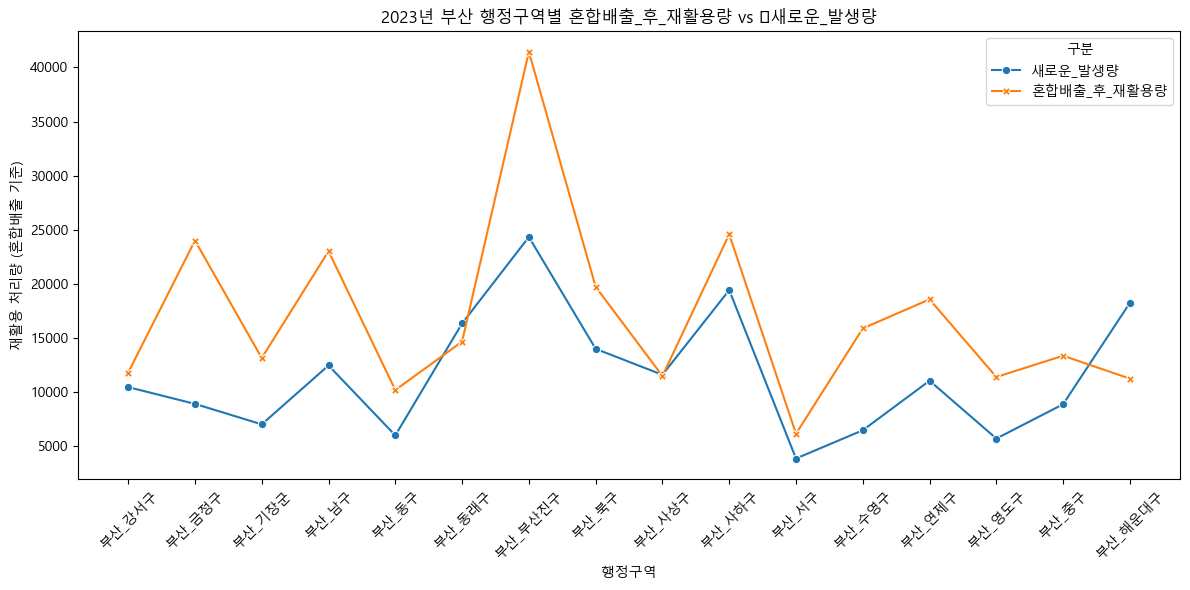

In [39]:
# 시군구별 예측값/실제값 형태 변환
df_plot = predicted_y[['행정구역', '새로운_발생량', '혼합배출_후_재활용량']].melt(id_vars='행정구역', var_name='구분', value_name='값')

# 시군구 이름 기준 정렬
order = predicted_y.sort_values(by='혼합배출_후_재활용량', ascending=False)['행정구역']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='행정구역', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.xticks(rotation=45)
plt.title('2023년 부산 행정구역별 혼합배출_후_재활용량 vs 	새로운_발생량')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('행정구역')
plt.tight_layout()
plt.legend(title='구분')

C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\830023757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')


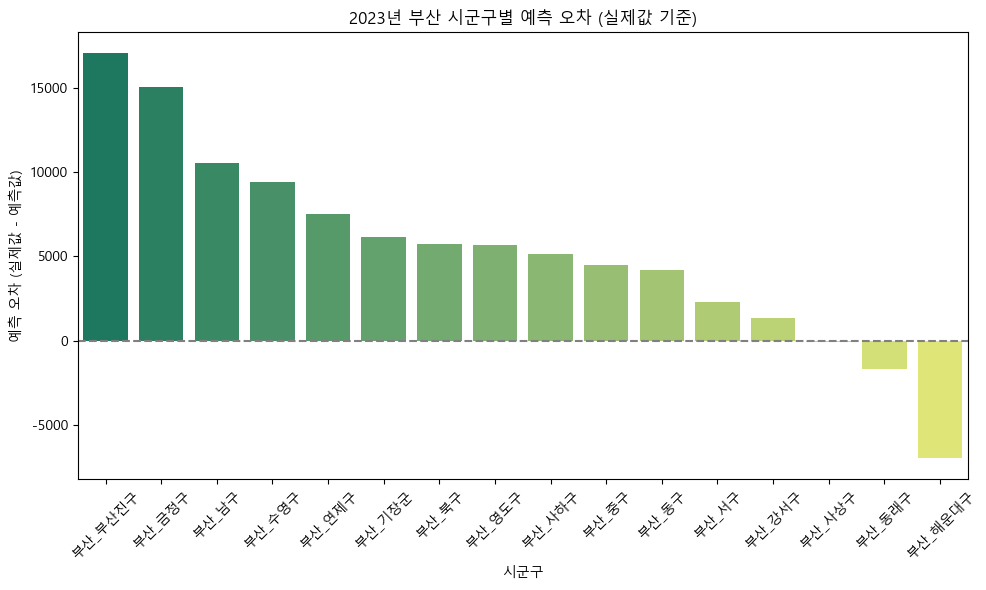

In [40]:
plt.figure(figsize=(10, 6))
df_sorted_heatmap = predicted_y.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()

In [67]:
# 원래는 예측값의 정답은 없지만 확인해보기
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 62689390.3990, RMSE: 7917.6632, R^2: 0.0632, MAE: 6467.3609


## 1-2 KBR 보리님 : '총인구수', '단독주택비율', '2인가구_비율', '4인가구_비율'

In [71]:
final_x_train = rf_x_train[['총인구수', '단독주택비율', '2인가구_비율', '4인가구_비율']]
final_x_test = rf_x_test[['총인구수', '단독주택비율', '2인가구_비율', '4인가구_비율']]

In [72]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(final_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
predictions = final_model.predict(final_x_test)
mse = mean_squared_error(rf_y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions)
mae = mean_absolute_error(rf_y_test, predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 144739659.3731, RMSE: 12030.7797, R^2: 0.4715, MAE: 6461.7671


In [74]:
model_to_evaluate = final_model

# 교차 검증, R^2 스코어 계산
scores = cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

# scoring을 'neg_mean_squared_error'로 변경 후 sqrt 적용해서 RMSE도 확인 
rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [-0.09199596  0.18076449 -0.2893397  -3.86332419 -0.22552392]
Mean R^2: -0.8579
Standard deviation of R^2: 1.5114
Cross-validation RMSE scores: [ 9233.40890675 15604.64044592  9372.76882363 14507.21664333
  6970.58699316]
Mean RMSE: 11137.7244
Standard deviation of RMSE: 3329.0640


In [75]:
# 원래는 예측값의 정답은 없지만 확인해보기
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 62689390.3990, RMSE: 7917.6632, R^2: 0.0632, MAE: 6467.3609


## 1-2 회귀 : '총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동'

In [77]:
final_x_train = rf_x_train [['총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']]
final_x_test = rf_x_test [['총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']]

In [78]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(final_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
predictions = final_model.predict(final_x_test)
mse = mean_squared_error(rf_y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions)
mae = mean_absolute_error(rf_y_test, predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 167652370.7063, RMSE: 12948.0644, R^2: 0.3878, MAE: 7040.5893


In [ ]:
model_to_evaluate = final_model

# 교차 검증, R^2 스코어 계산
scores = cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

# scoring을 'neg_mean_squared_error'로 변경 후 sqrt 적용해서 RMSE도 확인 
rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [-0.19971137  0.1640317  -0.07798807 -7.06040514  0.16985784]
Mean R^2: -1.4008
Standard deviation of R^2: 2.8333
Cross-validation RMSE scores: [ 9678.09632143 15763.19640259  8570.20491648 18676.51847658
  5736.99789359]
Mean RMSE: 11685.0028
Standard deviation of RMSE: 4787.9297


In [81]:
# 원래는 예측값의 정답은 없지만 확인해보기
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 62689390.3990, RMSE: 7917.6632, R^2: 0.0632, MAE: 6467.3609


# 모델 튜닝

predict test

여기서 선정한 피처 ✅ (이것이랑 비교!)  
MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761

보리  
MSE: 144739659.3731, RMSE: 12030.7797, R^2: 0.4715, MAE: 6461.7671

회귀  
MSE: 167652370.7063, RMSE: 12948.0644, R^2: 0.3878, MAE: 7040.5893

In [125]:
final_x_train = rf_x_train[['총인구수', '다세대주택비율', '3인가구_비율']]
# rf_y_train
final_x_test = rf_x_test[['총인구수', '다세대주택비율', '3인가구_비율']]
# rf_y_test 

In [126]:
base_rf_model = RandomForestRegressor(random_state=42)
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_leaf': [1, 2, 4, 8, 12],
    'min_samples_split': [2, 5, 10, 15, 20],
    'max_features': ['sqrt', 0.5, 0.7, 0.9, 1.0],
}

random_search = RandomizedSearchCV(estimator=base_rf_model,
                                   param_distributions=param_distributions,
                                   n_iter=50, # 탐색할 무작위 조합의 수 (예: 50개)
                                   cv=5,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1,
                                   verbose=2,
                                   random_state=42) # 재현성을 위해 random_state 설정

print("\n--- RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝 시작 ---")
random_search.fit(final_x_train, rf_y_train)

print("\n--- 튜닝 결과 (RandomizedSearchCV) ---")
print(f"찾아낸 최적 하이퍼파라미터: {random_search.best_params_}")
print(f"최적 교차 검증 RMSE: {np.sqrt(-random_search.best_score_):.4f}")

best_rf_model_rand = random_search.best_estimator_


--- RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝 시작 ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- 튜닝 결과 (RandomizedSearchCV) ---
찾아낸 최적 하이퍼파라미터: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 12, 'max_features': 0.5, 'max_depth': None}
최적 교차 검증 RMSE: 9583.0717


c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [127]:
# 테스트 예측
y_pred = best_rf_model_rand.predict(final_x_test)

print(f"테스트 세트 R²: {r2_score(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 RMSE: {np.sqrt(mean_squared_error(rf_y_test, y_pred)):.4f}")

테스트 세트 R²: 0.2637
테스트 세트 MSE: 201622282.7512
테스트 세트 RMSE: 14199.3761


In [131]:
# 기존 : MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761
201622282.7512 - 127905910.1162
## mse가 너무 크고 R2는 작음

73716372.63499999

- GridSearchCV로 조정

In [90]:
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [80, 100, 120, 150],
    'max_depth': [None, 25, 30],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [10,11,12,13,14,15],
    'max_features': ['sqrt', 0.4, 0.5, 0.6]
}

In [91]:
# 모델 정의 및 그리드서치
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
# 모델 훈련
grid_search.fit(final_x_train, rf_y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 25, ...], 'max_features': ['sqrt', 0.4, ...], 'min_samples_leaf': [10, 11, ...], 'min_samples_split': [2, 3, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,80


In [93]:
# 테스트 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(final_x_test)

# 성능 출력
print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
print(f"테스트 세트 R²: {r2_score(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(rf_y_test, y_pred):.4f}")


최적 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 2, 'n_estimators': 80}
최적 교차 검증 RMSE: 9576.3452
테스트 세트 R²: 0.2583
테스트 세트 MSE: 203106817.2964


In [133]:
# 기존 : MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761
203106817.2964 - 127905910.1162
## 동일하게 mse가 너무 크고 R2는 작음

75200907.18020001

- 다시 RandomizedSearchCV로 조정, 이번엔 scoring='r2'로!!

In [95]:
base_rf_model = RandomForestRegressor(random_state=42)
# param_distributions: 탐색할 하이퍼파라미터 분포 정의
# 여기서는 list 그대로 사용해도 되고, SciPy의 확률 분포 함수를 사용할 수도 있습니다.
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_leaf': [1, 2, 4, 8, 12],
    'min_samples_split': [2, 5, 10, 15, 20],
    'max_features': ['sqrt', 0.5, 0.7, 0.9, 1.0],
}

random_search = RandomizedSearchCV(estimator=base_rf_model,
                                   param_distributions=param_distributions,
                                   n_iter=100, # 탐색할 무작위 조합의 수 (예: 50개)
                                   cv=5,
                                   scoring='r2',
                                   n_jobs=-1,
                                   verbose=2,
                                   random_state=42) # 재현성을 위해 random_state 설정

print("\n--- RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝 시작 ---")
random_search.fit(final_x_train, rf_y_train)

print("\n--- 튜닝 결과 (RandomizedSearchCV) ---")
print(f"찾아낸 최적 하이퍼파라미터: {random_search.best_params_}")
print(f"최적 교차 검증 RMSE: {np.sqrt(-random_search.best_score_):.4f}")

best_rf_model_rand = random_search.best_estimator_


--- RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝 시작 ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits

--- 튜닝 결과 (RandomizedSearchCV) ---
찾아낸 최적 하이퍼파라미터: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
최적 교차 검증 RMSE: nan


c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\67987221.py:26: RuntimeWarning: invalid value encountered in sqrt
  print(f"최적 교차 검증 RMSE: {np.sqrt(-random_search.best_score_):.4f}")


In [96]:
best_rf_model_rand = random_search.best_estimator_
y_pred = best_rf_model_rand.predict(final_x_test)

# 성능 출력
# print(f"\n최적 파라미터: {random_search.best_params_}")
# print(f"최적 교차 검증 RMSE: {np.sqrt(-random_search.best_score_):.4f}")
print(f"테스트 세트 R²: {r2_score(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(rf_y_test, y_pred):.4f}")

테스트 세트 R²: 0.4145
테스트 세트 MSE: 160335577.8173


In [135]:
# 기존 : MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761
160335577.8173 - 127905910.1162
## mse가 작아졌지만 동일하게 mse가 너무 크고 R2는 작음

32429667.70109999

- 다시 GridSearchCV로 조정, 동일하게 scoring='r2'로!!

In [99]:
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [80, 100, 120, 150],
    'max_depth': [None, 25, 30, 35],
    'min_samples_split': [8,10,12,14],
    'min_samples_leaf': [1,2,3],
    'max_features': ['sqrt', 0.2, 0.4, 0.6]
}

# 모델 정의 및 그리드서치
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
# 모델 훈련
grid_search.fit(final_x_train, rf_y_train)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits


c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 25, ...], 'max_features': ['sqrt', 0.2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [8, 10, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,80


In [100]:
# 테스트 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(final_x_test)

# 성능 출력
print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
print(f"테스트 세트 R²: {r2_score(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(rf_y_test, y_pred):.4f}")



최적 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 12, 'n_estimators': 80}
최적 교차 검증 RMSE: nan
테스트 세트 R²: 0.3745
테스트 세트 MSE: 171298135.2411


C:\Users\nammi\AppData\Local\Temp\ipykernel_10100\170068017.py:7: RuntimeWarning: invalid value encountered in sqrt
  print(f"최적 교차 검증 RMSE: {np.sqrt(-grid_search.best_score_):.4f}")


In [138]:
# 기존 : MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761
171298135.2411 - 127905910.1162
## 동일하게 mse가 너무 크고 R2는 작음

43392225.12490001

randomized(mse) -> grid(mse) -> randomized(r2) -> grid(r2)  
'n_estimators': 100 -> 80 -> 100 -> 80  
'min_samples_split': 2 ->2 -> 10 -> 12  
'min_samples_leaf': 12 -> 11 -> 1 -> 2  
'max_features': 0.5 -> sqrt -> sqrt -> sqrt  
'max_depth': None -> None -> 30 -> None  

- 찐막

In [117]:
# 하이퍼파라미터 후보 설정
param_grid = {
    'min_samples_split': [2, 4, 8, 12],
    'n_estimators':[100, 110,120],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt'],
    'max_depth':[10,11,12]
}

# 모델 정의 및 그리드서치
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
# 모델 훈련
grid_search.fit(final_x_train, rf_y_train)
# 테스트 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(final_x_test)

# 성능 출력
print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 RMSE: {np.sqrt(grid_search.best_score_):.4f}")
print(f"테스트 세트 R²: {r2_score(rf_y_test, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(rf_y_test, y_pred):.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits

최적 파라미터: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}
최적 교차 검증 RMSE: 0.3182
테스트 세트 R²: 0.4492
테스트 세트 MSE: 150821689.0080


c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [118]:
model_to_evaluate = best_model
scores = cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, final_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [ 0.08187425  0.18734569  0.07140816 -0.11401317  0.27954879]
Mean R^2: 0.1012
Standard deviation of R^2: 0.1318
Cross-validation RMSE scores: [ 8466.4751027  15541.83542748  7954.20282318  6943.24753616
  5344.54507126]
Mean RMSE: 8850.0612
Standard deviation of RMSE: 3511.5274


# 결론:
튜닝전: 가장 낮은 mse, 가장 높은 R2, 안좋은 교차검증 결과
튜닝후: 교차검증 결과는 best는 아니지만 튜닝전보다 조금 더 좋음

> 튜닝 전 테스트 세트 성능 (R² 0.5329)은 과대평가되었을 가능성이 매우 높음  
> 피처 선정 방법을 mse로 진행해 봐야겠음 (12차_kbr_test_mse.ipynb)